# Markowitz portfolio optimisation with OSQP

The basic mean-variance model (Markowitz, 1952; Beasley, 2013) chooses the proportion $w_i$ of the budget invested in each of $N$ assets:

$$
\min_{w}\; \sum_{i=1}^{N}\sum_{j=1}^{N}\sigma_{ij}w_i w_j
\quad\text{s.t.}\quad \sum_{i=1}^{N}\mu_i w_i = R_{\min},\qquad \sum_{i=1}^{N}w_i = 1,\qquad w_i \ge 0 .
$$

Solving it for many values of $R_{\min}$ traces the **unconstrained efficient frontier** (UEF). This notebook does it for the five OR-Library instances `port1`–`port5` with the QP solver [OSQP](https://osqp.org) and compares the result with the reference frontiers `portef1`–`portef5`.

1. Load the data
2. The model in OSQP form
3. Solve the frontiers
4. Results: computational times and plots

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import osqp
import pandas as pd
import scipy.sparse as sp

DATA_DIR = Path("data")
INSTANCES = {1: "Hang Seng", 2: "DAX 100", 3: "FTSE 100", 4: "S&P 100", 5: "Nikkei 225"}
print("OSQP", osqp.__version__)

OSQP 1.1.3


## 1. Load the data

`portK.txt` holds the number of assets $N$, then one line per asset with its mean return $\mu_i$ and standard deviation $s_i$, and then one line `i j rho_ij` for every pair $i \le j$. The covariance is $\sigma_{ij} = \rho_{ij}\, s_i\, s_j$.

`portefK.txt` holds 2000 points (mean return, variance) of the reference UEF, from the minimum-variance portfolio up to the asset with the highest mean return.

In [2]:
def read_port(k):
    """Mean returns, standard deviations and covariance matrix of instance port{k}."""
    values = (DATA_DIR / f"port{k}.txt").read_text().split()
    n = int(values[0])
    data = np.array(values[1:], dtype=float)
    mu, sd = data[: 2 * n].reshape(n, 2).T
    pairs = data[2 * n :].reshape(-1, 3)  # i, j, correlation (i <= j, 1-based)
    i, j = pairs[:, 0].astype(int) - 1, pairs[:, 1].astype(int) - 1
    corr = np.zeros((n, n))
    corr[i, j] = corr[j, i] = pairs[:, 2]
    return mu, sd, corr * np.outer(sd, sd)


def read_portef(k):
    """Reference frontier of port{k}: mean returns and variances, sorted by return."""
    R, V = np.loadtxt(DATA_DIR / f"portef{k}.txt").T
    order = np.argsort(R)
    return R[order], V[order]


data = {k: read_port(k) for k in INSTANCES}
bench = {k: read_portef(k) for k in INSTANCES}

pd.DataFrame(
    {
        "index": INSTANCES.values(),
        "N": [len(data[k][0]) for k in INSTANCES],
        "min mean return": [data[k][0].min() for k in INSTANCES],
        "max mean return": [data[k][0].max() for k in INSTANCES],
        "min eigenvalue of Sigma": [np.linalg.eigvalsh(data[k][2]).min() for k in INSTANCES],
        "portef points": [len(bench[k][0]) for k in INSTANCES],
    },
    index=[f"port{k}" for k in INSTANCES],
)

,index,N,min mean return,max mean return,min eigenvalue of Sigma,portef points
port1,Hang Seng,31,0.000141,0.010865,0.000226,2000
port2,DAX 100,85,-0.004002,0.009794,0.000082,2000
port3,FTSE 100,89,-0.001126,0.008209,0.000059,2000
port4,S&P 100,98,-0.001980,0.009195,0.000081,2000
port5,Nikkei 225,225,-0.008489,0.003971,0.000006,2000


All covariance matrices are positive definite, so every QP is convex with a unique optimum.

## 2. The model in OSQP form

OSQP solves $\min_w \tfrac12 w^\top P w + q^\top w$ subject to $l \le Aw \le u$, where $w$ is the vector of portfolio weights (the OSQP documentation calls the variable $x$). Our model maps to

$$
P = 2\Sigma,\quad q = 0,\qquad
A = \begin{bmatrix}\mu^\top\\ \mathbf 1^\top\\ I\end{bmatrix},\quad
l = \begin{bmatrix}R_{\min}\\ 1\\ 0\end{bmatrix},\quad
u = \begin{bmatrix}+\infty\\ 1\\ +\infty\end{bmatrix}.
$$

Why OSQP fits this problem:

* **One factorisation for the whole frontier.** Along the frontier only $l_1 = R_{\min}$ changes. OSQP factorises its KKT matrix once in `setup`, and `update(l=...)` changes the bound without refactorising.
* **Warm start.** Each solve starts from the previous portfolio, which is very close to the next one.
* **Accuracy settings.** OSQP is a first-order (ADMM) method. Its default tolerance (`1e-3`) is too loose for variances of order $10^{-4}$, so we use `eps_abs = eps_rel = 1e-6` and turn on *solution polishing*, which refines the ADMM solution on its active set. We also raise the iteration limit from 4000 to 20000, because the points close to the maximum return need many iterations (see the note at the end).

In [3]:
SETTINGS = dict(eps_abs=1e-6, eps_rel=1e-6, polishing=True, max_iter=20_000, verbose=False)


def build_qp(mu, Sigma, R_min):
    """P, q, A, l, u of the Markowitz model for OSQP."""
    n = len(mu)
    P = sp.csc_matrix(np.triu(2 * Sigma))  # OSQP only reads the upper triangle
    q = np.zeros(n)
    A = sp.vstack([mu, np.ones(n), sp.eye(n)], format="csc")
    l = np.r_[R_min, 1.0, np.zeros(n)]
    u = np.r_[np.inf, 1.0, np.full(n, np.inf)]
    return P, q, A, l, u

### Example: a single portfolio (port1, $R_{\min} = 0.008$)

In [4]:
mu, sd, Sigma = data[1]
solver = osqp.OSQP()
solver.setup(*build_qp(mu, Sigma, R_min=0.008), **SETTINGS)
res = solver.solve()
w = res.x

print(f"status: {res.info.status}, {res.info.iter} iterations, {1e3 * res.info.run_time:.2f} ms")
print(f"return = {mu @ w:.6f}   variance = {w @ Sigma @ w:.6e}   sum of weights = {w.sum():.6f}")
print("assets held:", {i + 1: round(float(wi), 4) for i, wi in enumerate(w) if wi > 1e-6})

status: solved, 125 iterations, 1.00 ms
return = 0.008000   variance = 1.545024e-03   sum of weights = 1.000000
assets held: {5: 0.4009, 9: 0.1674, 26: 0.0566, 29: 0.3751}


## 3. Solve the frontiers

For each instance we solve the QP at the **2000 return levels of `portefK`**. Our variances can then be compared with the benchmark point by point. The problem is set up once and re-solved with the new $R_{\min}$ and a warm start. The measured time includes the setup.

In [5]:
def solve_frontier(mu, Sigma, R_levels):
    """Solve the QP for every R_min in R_levels. Returns variances, statuses, iterations, seconds."""
    P, q, A, l, u = build_qp(mu, Sigma, R_levels[0])
    start = time.perf_counter()
    solver = osqp.OSQP()
    solver.setup(P, q, A, l, u, **SETTINGS)
    variance, status, iterations = [], [], []
    for R in R_levels:
        l[0] = R
        solver.update(l=l)
        res = solver.solve(raise_error=False)
        variance.append(res.x @ Sigma @ res.x)
        status.append(res.info.status)
        iterations.append(res.info.iter)
    seconds = time.perf_counter() - start
    return np.array(variance), np.array(status), np.array(iterations), seconds


results = {}
for k in INSTANCES:
    mu, sd, Sigma = data[k]
    results[k] = solve_frontier(mu, Sigma, bench[k][0])
    print(f"port{k}: {len(bench[k][0])} QPs in {results[k][3]:.1f} s")

port1: 2000 QPs in 0.8 s
port2: 2000 QPs in 25.6 s
port3: 2000 QPs in 9.8 s
port4: 2000 QPs in 32.8 s
port5: 2000 QPs in 183.9 s


## 4. Results

### Computational times and accuracy

The deviation from the benchmark is $100\,(V_{\text{OSQP}} - V_{\text{portef}})/V_{\text{portef}}$ at the same return level, computed over the points OSQP reports as `solved`. `portef` prints variances with 10 decimals, so deviations of about $10^{-5}\,\%$ are the rounding of the file. A few `solved` points deviate by up to $\sim 0.1\,\%$. At those points polishing failed, so the solution is only as accurate as the ADMM tolerance: the return constraint is violated by $\sim 10^{-8}$, which gives a slightly lower variance.

In [6]:
rows = []
for k in INSTANCES:
    V, status, iterations, seconds = results[k]
    V_ref = bench[k][1]
    ok = status == "solved"
    dev = 100 * (V[ok] - V_ref[ok]) / V_ref[ok]
    rows.append(
        {
            "index": INSTANCES[k],
            "N": len(data[k][0]),
            "QPs": len(V),
            "time (s)": seconds,
            "ms per QP": 1e3 * seconds / len(V),
            "mean iterations": iterations.mean(),
            "not solved": int((~ok).sum()),
            "max |dev| (%)": np.abs(dev).max(),
            "mean |dev| (%)": np.abs(dev).mean(),
        }
    )
table = pd.DataFrame(rows, index=[f"port{k}" for k in INSTANCES])
table.style.format(
    {"time (s)": "{:.2f}", "ms per QP": "{:.2f}", "mean iterations": "{:.0f}",
     "max |dev| (%)": "{:.1e}", "mean |dev| (%)": "{:.1e}"}
)

,index,N,QPs,time (s),ms per QP,mean iterations,not solved,max |dev| (%),mean |dev| (%)
port1,Hang Seng,31,2000,0.87,0.44,76,0,7.8e-06,2.9e-06
port2,DAX 100,85,2000,25.93,12.96,797,0,3.6e-05,1.0e-05
port3,FTSE 100,89,2000,10.08,5.04,255,0,3.8e-02,3.6e-05
port4,S&P 100,98,2000,33.90,16.95,803,3,1.0e-02,1.7e-05
port5,Nikkei 225,225,2000,274.96,137.48,974,60,1.1e-01,1.2e-04


In [7]:
for k in INSTANCES:
    status = results[k][1]
    bad = np.flatnonzero(status != "solved")
    if bad.size:
        R = bench[k][0]
        labels, counts = np.unique(status[bad], return_counts=True)
        print(f"port{k}: {bad.size} points not solved, R from {R[bad[0]]:.6f} to {R[bad[-1]]:.6f}"
              f" (R_max = {R[-1]:.6f})")
        print("   ", dict(zip(labels.tolist(), counts.tolist())))

port4: 3 points not solved, R from 0.009090 to 0.009097 (R_max = 0.009195)
    {'solved inaccurate': 3}
port5: 60 points not solved, R from 0.003856 to 0.003971 (R_max = 0.003971)
    {'maximum iterations reached': 44, 'solved inaccurate': 16}


### Efficient frontiers

Each panel shows our frontier (points solved by OSQP), the benchmark points of `portef` and the individual assets. The assets are inefficient portfolios: they lie below and to the right of the frontier. The last panel shows the deviation from the benchmark along the frontier.

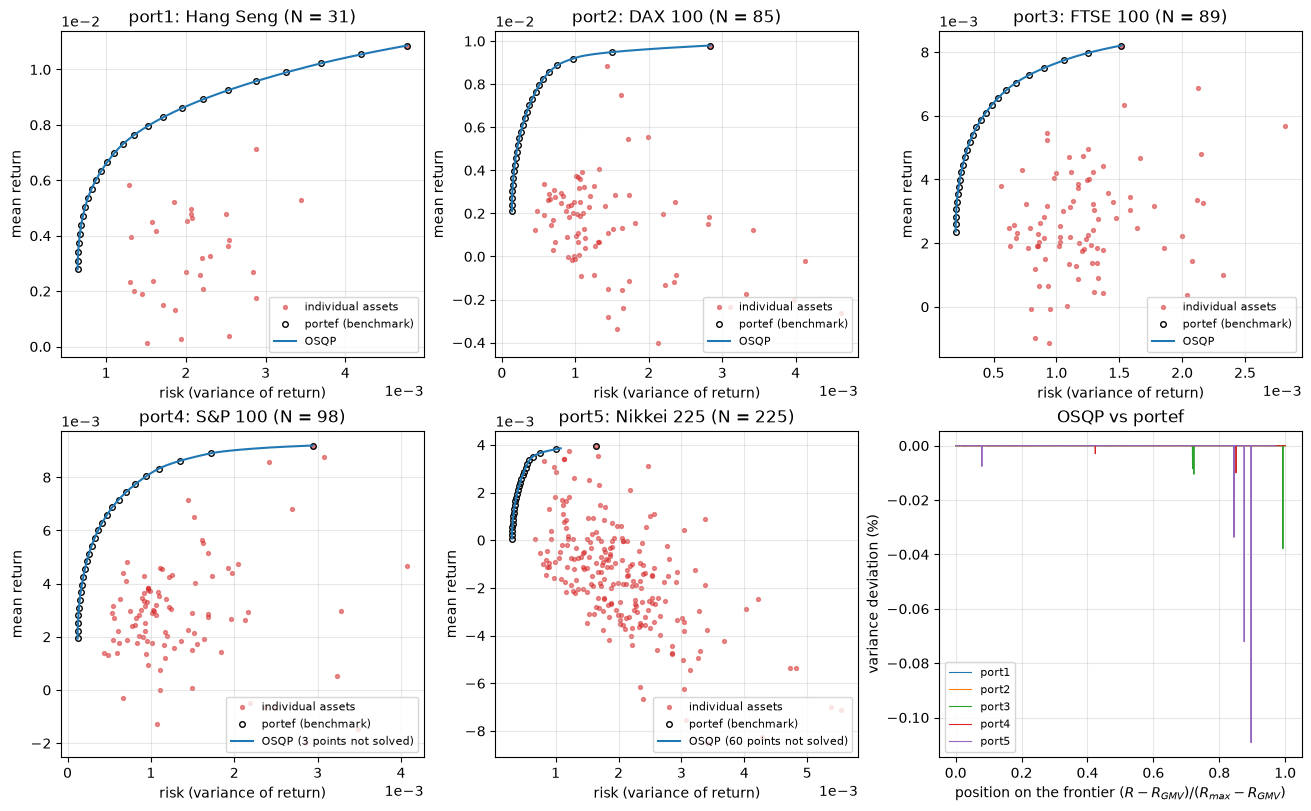

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8), layout="constrained")

for ax, k in zip(axes.flat, INSTANCES):
    mu, sd, Sigma = data[k]
    R_ref, V_ref = bench[k]
    V, status, _, _ = results[k]
    ok = status == "solved"
    n_bad = int((~ok).sum())
    marks = np.linspace(0, len(R_ref) - 1, 26).astype(int)  # 26 benchmark points, both ends included
    ax.scatter(sd**2, mu, s=8, color="tab:red", alpha=0.5, label="individual assets")
    ax.plot(V_ref[marks], R_ref[marks], "o", mfc="none", color="black", ms=4, label="portef (benchmark)")
    ax.plot(V[ok], R_ref[ok], color="tab:blue", lw=1.5,
            label="OSQP" + (f" ({n_bad} points not solved)" if n_bad else ""))
    ax.set(title=f"port{k}: {INSTANCES[k]} (N = {len(mu)})", xlabel="risk (variance of return)",
           ylabel="mean return")
    ax.ticklabel_format(style="sci", scilimits=(-2, 2))
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)

ax = axes.flat[5]
for k in INSTANCES:
    R_ref, V_ref = bench[k]
    V, status, _, _ = results[k]
    ok = status == "solved"
    position = (R_ref - R_ref[0]) / (R_ref[-1] - R_ref[0])
    ax.plot(position[ok], 100 * (V[ok] - V_ref[ok]) / V_ref[ok], lw=0.8, label=f"port{k}")
ax.set(title="OSQP vs portef", xlabel=r"position on the frontier $(R-R_{GMV})/(R_{max}-R_{GMV})$",
       ylabel="variance deviation (%)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/frontiers.pdf")
fig.savefig("figures/frontiers.png", dpi=200)
plt.show()

### Note on the points that are not solved

All of them lie at the top end of the frontier, close to $R_{\max}$. There the return constraint can only be met by investing almost everything in the asset with the highest mean return. The feasible set shrinks to a thin corner of the simplex, and at $R_{\max}$ it is a single point with no strictly feasible portfolio. A first-order method such as ADMM converges very slowly on such problems, and OSQP stops with `solved inaccurate` or `maximum iterations reached`.

The iteration limit matters. With OSQP's default of 4000 iterations, port2, port4 and port5 lose 121, 82 and 125 points, and some feasible problems are even reported as `primal infeasible inaccurate`. With 20000 iterations only port4 and port5 keep a few failures, but port5 takes about twice as long.

Changing `rho`, disabling scaling, writing the return constraint as an equality or normalising it did not fix these points. What works:

* A much tighter tolerance with many more iterations: every point is then solved, but port5 takes about 8.5 minutes (see `markowitz_osqp.py`).
* The equivalent weighted formulation $\min\, w^\top\Sigma w - t\,\mu^\top w$, whose feasible set is always the whole simplex.
* An active-set or interior-point solver (HiGHS, Gurobi, CPLEX).